In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
import pandas as pd
df = pd.read_csv('ecommerce_sales_34500.csv')
df.head(5)



,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male


In [2]:
df.shape
df.dtypes
df.isnull().sum()

order_id              0
customer_id           0
product_id            0
category              0
price                 0
discount              0
quantity              0
payment_method        0
order_date            0
delivery_time_days    0
region                0
returned              0
total_amount          0
shipping_cost         0
profit_margin         0
customer_age          0
customer_gender       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)


In [ ]:
# transforming date columns into correct datetime formal

df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

In [32]:
# total sale

total_sales = df['total_amount'].round(0).astype(int).sum()

print(f"Total Sales: ₹{total_sales:,.2f}")

Total Sales: ₹5,865,101.00


In [23]:
# Highest Selling Product by Revenue

product_sales = (
    df.groupby('product_id')['total_amount']
      .sum()
      .sort_values(ascending=False)
)

print("Top 10 Products by Sales:")
print(product_sales.head(10).round(0).astype(int))

highest_selling_product = product_sales.idxmax()
highest_product_sales = product_sales.max()

print(f"\nHighest Selling Product: {highest_selling_product}")
print(f"Revenue Generated: ₹{highest_product_sales:,.0f}")

Top 10 Products by Sales:
product_id
P217031    13035
P242326    11747
P224743    11298
P216077     8036
P225406     6787
P204291     6279
P208695     6227
P219612     6033
P247375     5663
P218610     5438
Name: total_amount, dtype: int64

Highest Selling Product: P217031
Revenue Generated: ₹13,035


In [11]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [ ]:
# monthly sales  

monthly_sales = (
    df.groupby(df['order_date'].dt.to_period('M'))['total_amount']
      .sum()
      .round(0)
      .astype(int)
)

print("Monthly Sales:")
print(monthly_sales)

Monthly Sales:
order_date
2023-09    151136
2023-10    262503
2023-11    240287
2023-12    255617
2024-01    217766
2024-02    228014
2024-03    248176
2024-04    265597
2024-05    264875
2024-06    234155
2024-07    253369
2024-08    212613
2024-09    218874
2024-10    258931
2024-11    250572
2024-12    278154
2025-01    224390
2025-02    215338
2025-03    239347
2025-04    263024
2025-05    248527
2025-06    248776
2025-07    249594
2025-08    243808
2025-09     91848
Freq: M, Name: total_amount, dtype: int64


In [28]:
# Region-wise Sales

region_sales = (
    df.groupby('region')['total_amount']
      .sum()
      .round(0)
      .astype(int)
      .sort_values(ascending=False)
)

print("Region-wise Sales:")
print(region_sales)

Region-wise Sales:
region
South      1298096
North      1264008
West       1186350
East       1176335
Central     940503
Name: total_amount, dtype: int64


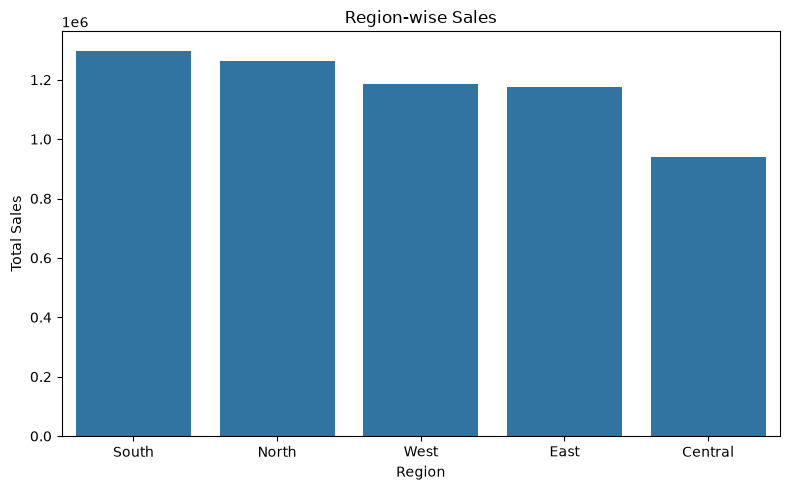

In [17]:

#  BAR CHART - REGION-WISE SALES


plt.figure(figsize=(8, 5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title('Region-wise Sales')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

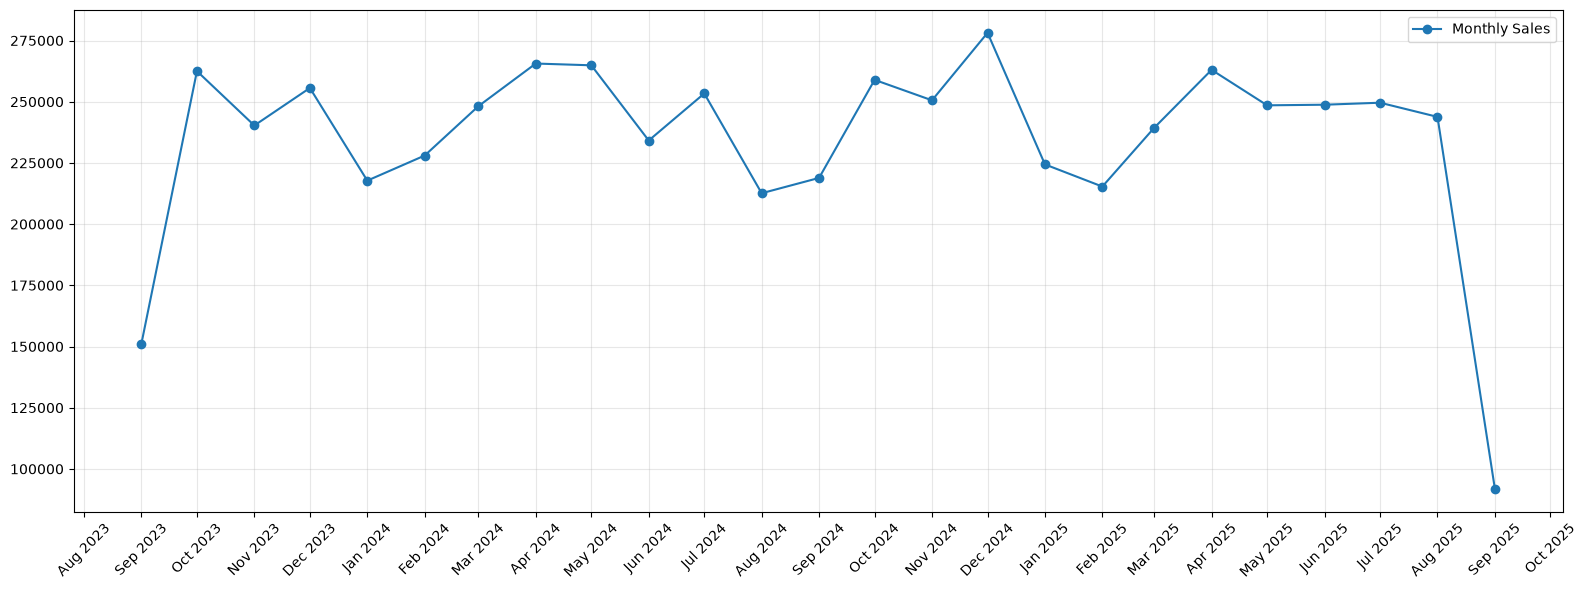

In [41]:
# mouthly 
plt.figure(figsize=(16, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', label='Monthly Sales')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

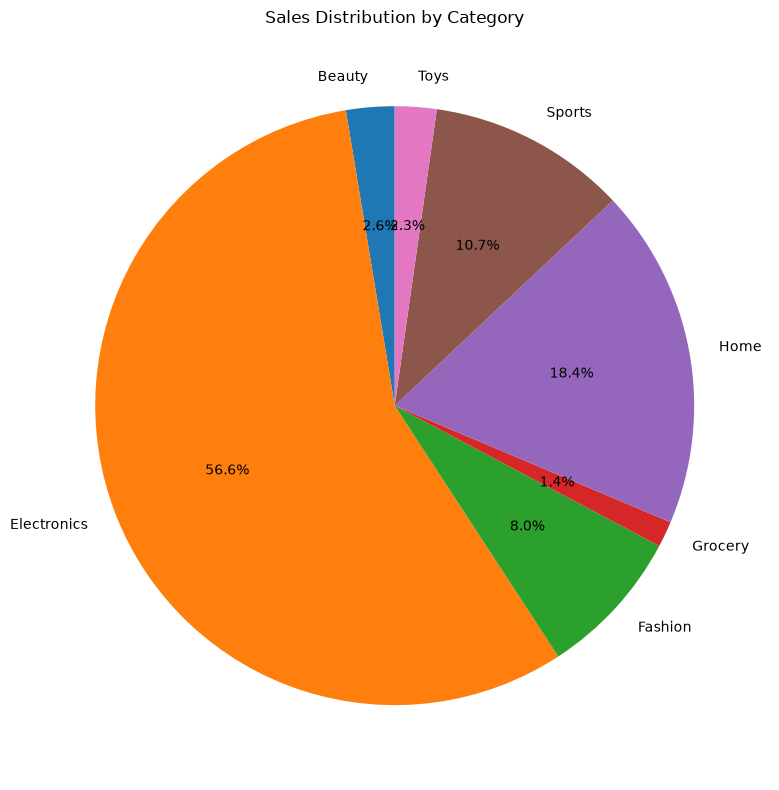

In [ ]:

#  PIE CHART - CATEGORY-WISE SALES


category_sales = df.groupby('category')['total_amount'].sum()

plt.figure(figsize=(8, 8))

plt.pie(
    category_sales.values,
    labels=category_sales.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Sales Distribution by Category')
plt.tight_layout()
plt.show()

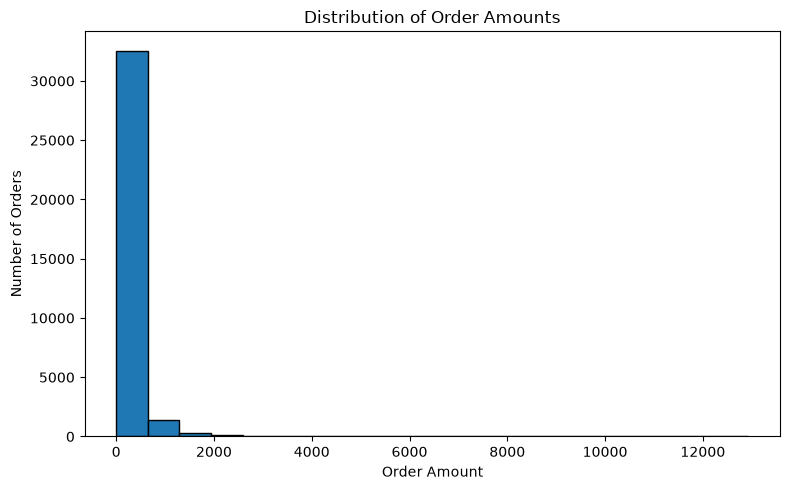

In [21]:

#  HISTOGRAM  ORDER AMOUNT DISTRIBUTION

plt.figure(figsize=(8, 5))

plt.hist(
    df['total_amount'],
    bins=20,
    edgecolor='black'
)

plt.title('Distribution of Order Amounts')
plt.xlabel('Order Amount')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

## Insight Interpretation

The analysis shows overall sales performance across products, months, regions, and categories. **P217031** is the highest-selling product by revenue. Monthly trends show periods of sales growth and decline, while region-wise analysis identifies stronger and weaker-performing regions. The category-wise pie chart shows the contribution of each category, and the histogram highlights the distribution of order amounts. These insights can help improve **sales planning, marketing, inventory, and regional strategies**.
